# WTI Other Reportables — Correlation with Other Trader Categories

Who do Other Reportables trade like? Correlate their weekly positioning
changes against each of the other 4 CFTC disaggregated categories.

Two views:
- **Raw net changes** — absolute contract changes
- **Net/OI changes** — scaled by open interest, normalises for market size

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load WTI disaggregated COT (NYMEX + ICE combined)

In [10]:
RAW_PATH = '/Users/oualid/Documents/Projects/omroot_repos/cftc_data/cftc_downloads/disaggregated_combined.csv'

raw = pd.read_csv(RAW_PATH, low_memory=False)

# WTI requires combining two contracts:
#   067651 = WTI-PHYSICAL (NYMEX)
#   067411 = CRUDE OIL, LIGHT SWEET-WTI (ICE, listed on NYMEX)
# This matches the cot-ingest pipeline which sums both.
WTI_CODES = ['067651', '067411']
wti_raw = raw[raw['cftc_contract_market_code'].isin(WTI_CODES)].copy()

print(f'Rows per contract:')
print(wti_raw.groupby('contract_market_name')['report_date_as_yyyy_mm_dd'].count().to_string())

# Parse dates
wti_raw['as_of_date'] = pd.to_datetime(wti_raw['report_date_as_yyyy_mm_dd'])

# Numeric columns we need to sum across contracts
POS_COLS = [
    'open_interest_all',
    'prod_merc_positions_long', 'prod_merc_positions_short',
    'swap_positions_long_all', 'swap__positions_short_all',
    'm_money_positions_long_all', 'm_money_positions_short_all',
    'other_rept_positions_long', 'other_rept_positions_short',
    'nonrept_positions_long_all', 'nonrept_positions_short_all',
]
for c in POS_COLS:
    wti_raw[c] = pd.to_numeric(wti_raw[c], errors='coerce')

# Sum positions across the two contracts for each report date
wti = wti_raw.groupby('as_of_date')[POS_COLS].sum().reset_index()

# Release date
days_ahead = (4 - wti['as_of_date'].dt.dayofweek) % 7
wti['release_date'] = wti['as_of_date'] + pd.to_timedelta(days_ahead, unit='D')
wti['open_interest'] = wti['open_interest_all']

wti.sort_values('as_of_date', inplace=True)
wti.reset_index(drop=True, inplace=True)

print(f'\nCombined WTI rows: {len(wti)}')
print(f'Date range: {wti["as_of_date"].min().date()} -> {wti["as_of_date"].max().date()}')


Rows per contract:
contract_market_name
CRUDE OIL, LIGHT SWEET-WTI     870
WTI-PHYSICAL                  1033

Combined WTI rows: 1033
Date range: 2006-06-13 -> 2026-03-24


In [11]:
CATEGORIES = {
    'Producer/Merchant': ('prod_merc_positions_long', 'prod_merc_positions_short'),
    'Swap Dealers':      ('swap_positions_long_all', 'swap__positions_short_all'),
    'Managed Money':     ('m_money_positions_long_all', 'm_money_positions_short_all'),
    'Other Reportables': ('other_rept_positions_long', 'other_rept_positions_short'),
    'Non-Reportables':   ('nonrept_positions_long_all', 'nonrept_positions_short_all'),
}

COLORS = {
    'Producer/Merchant': 'tab:red',
    'Swap Dealers':      'tab:purple',
    'Managed Money':     'tab:blue',
    'Other Reportables': 'tab:orange',
    'Non-Reportables':   'tab:grey',
}

OTHERS_VS = [c for c in CATEGORIES if c != 'Other Reportables']

# Build raw net and net/OI for all categories
net_raw = {}
net_oi  = {}
oi = wti['open_interest'].values

for cat, (long_col, short_col) in CATEGORIES.items():
    long_pos  = pd.to_numeric(wti[long_col], errors='coerce').values
    short_pos = pd.to_numeric(wti[short_col], errors='coerce').values
    net = long_pos - short_pos
    net_raw[cat] = net
    net_oi[cat]  = net / oi * 100

dates = wti['as_of_date'].values

raw_df = pd.DataFrame(net_raw, index=dates).sort_index()
oi_df  = pd.DataFrame(net_oi, index=dates).sort_index()

# Weekly changes
raw_chg = raw_df.diff().dropna()
oi_chg  = oi_df.diff().dropna()

print(f'Weekly changes: {len(raw_chg)} weeks')

Weekly changes: 1032 weeks


## 2. Net positioning levels

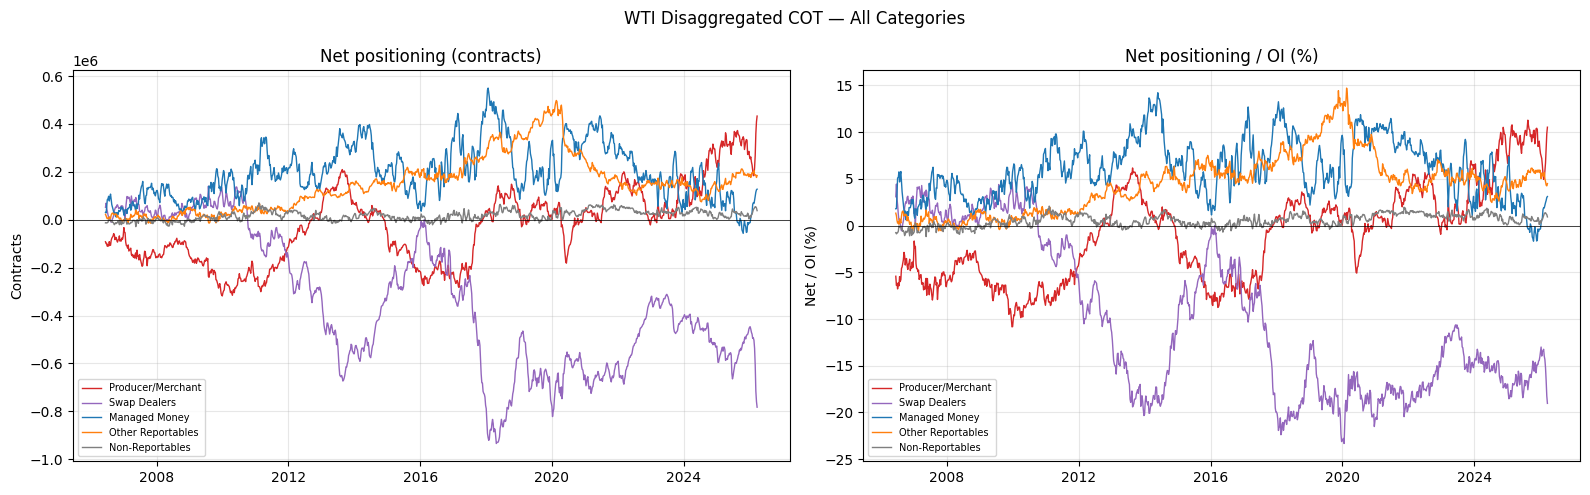

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for cat in CATEGORIES:
    axes[0].plot(raw_df.index, raw_df[cat], label=cat, color=COLORS[cat], lw=1)
    axes[1].plot(oi_df.index, oi_df[cat], label=cat, color=COLORS[cat], lw=1)

axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_title('Net positioning (contracts)')
axes[0].set_ylabel('Contracts')
axes[0].legend(fontsize=7, loc='lower left')

axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_title('Net positioning / OI (%)')
axes[1].set_ylabel('Net / OI (%)')
axes[1].legend(fontsize=7, loc='lower left')

plt.suptitle('WTI Disaggregated COT — All Categories', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Full-sample correlations

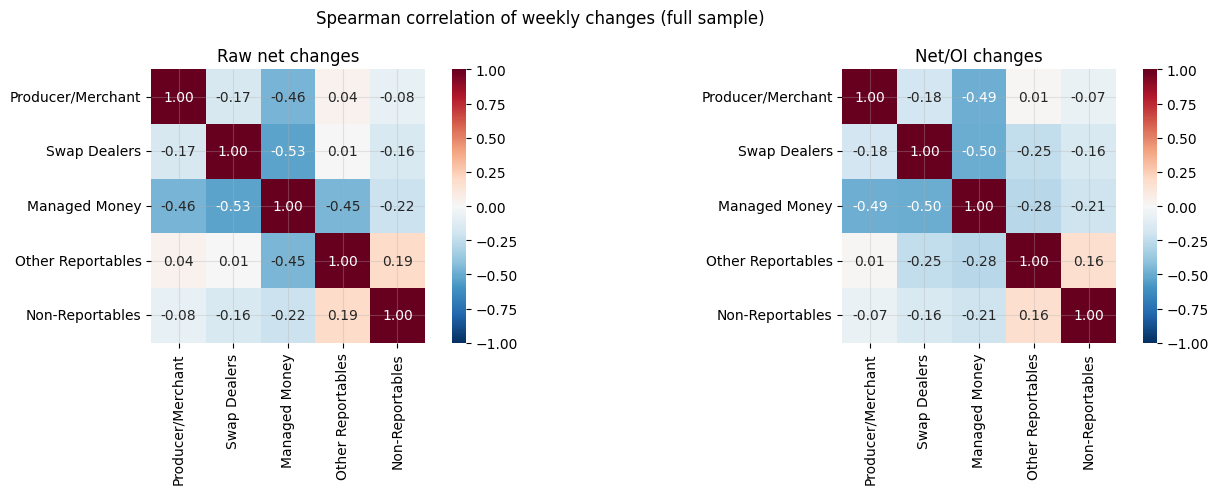

Category                    Raw net chg    Net/OI chg
-------------------------------------------------------
Producer/Merchant                +0.040        +0.009
Swap Dealers                     +0.007        -0.249
Managed Money                    -0.455        -0.279
Non-Reportables                  +0.194        +0.164


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, chg_df, title in [
    (axes[0], raw_chg, 'Raw net changes'),
    (axes[1], oi_chg,  'Net/OI changes'),
]:
    corr = chg_df.corr(method='spearman')
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, ax=ax, square=True)
    ax.set_title(title)

plt.suptitle('Spearman correlation of weekly changes (full sample)', fontsize=12)
plt.tight_layout()
plt.show()

# Summary table
print(f'{"Category":25s}  {"Raw net chg":>12s}  {"Net/OI chg":>12s}')
print('-' * 55)
for cat in OTHERS_VS:
    rho_raw, _ = sp_stats.spearmanr(raw_chg['Other Reportables'], raw_chg[cat])
    rho_oi, _  = sp_stats.spearmanr(oi_chg['Other Reportables'], oi_chg[cat])
    print(f'{cat:25s}  {rho_raw:+12.3f}  {rho_oi:+12.3f}')

## 4. Rolling 52-week correlation

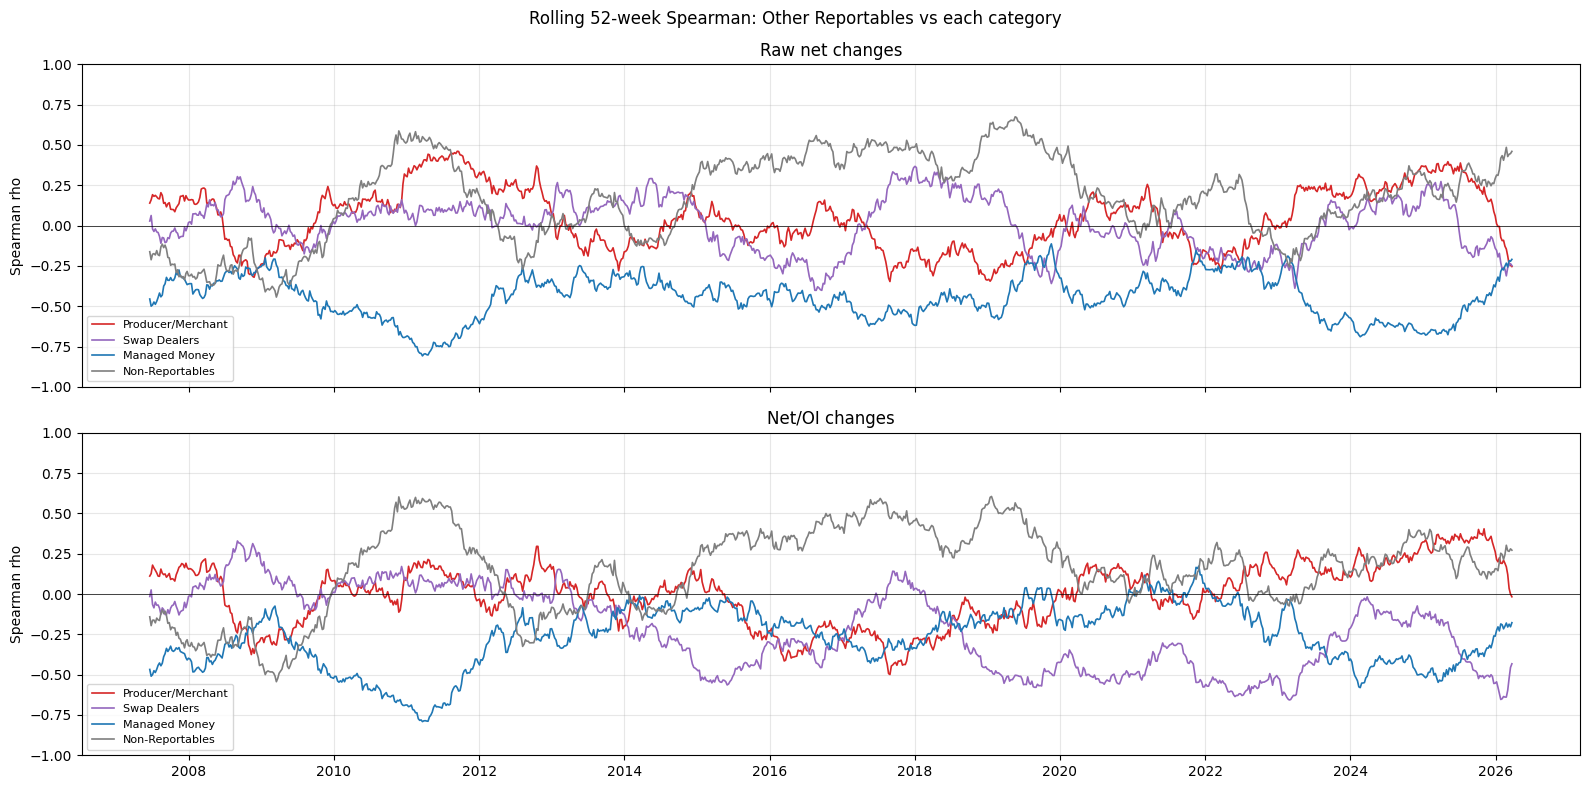

In [14]:
WINDOW = 52

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for ax, chg_df, title in [
    (axes[0], raw_chg, 'Raw net changes'),
    (axes[1], oi_chg,  'Net/OI changes'),
]:
    other = chg_df['Other Reportables'].values
    for cat in OTHERS_VS:
        vals = chg_df[cat].values
        rhos = [
            sp_stats.spearmanr(other[i-WINDOW:i], vals[i-WINDOW:i]).statistic
            if i >= WINDOW else float('nan')
            for i in range(len(other))
        ]
        ax.plot(chg_df.index, rhos, label=cat, color=COLORS[cat], lw=1.2)
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(f'{title}')
    ax.set_ylabel('Spearman rho')
    ax.set_ylim(-1, 1)
    ax.legend(loc='lower left', fontsize=8)

plt.suptitle(f'Rolling {WINDOW}-week Spearman: Other Reportables vs each category', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Year-by-year correlation

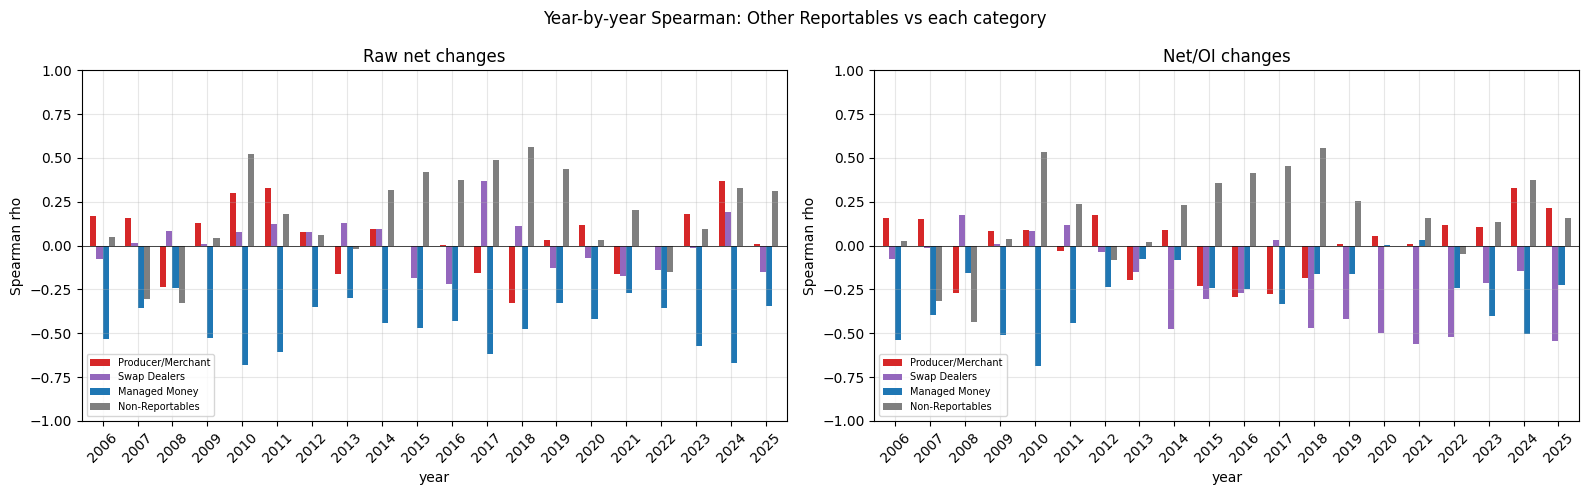

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, chg_df, title in [
    (axes[0], raw_chg, 'Raw net changes'),
    (axes[1], oi_chg,  'Net/OI changes'),
]:
    chg_yr = chg_df.copy()
    chg_yr['year'] = chg_yr.index.year

    yearly = []
    for year, grp in chg_yr.groupby('year'):
        if len(grp) < 20:
            continue
        row = {'year': year}
        for cat in OTHERS_VS:
            rho, _ = sp_stats.spearmanr(grp['Other Reportables'], grp[cat])
            row[cat] = rho
        yearly.append(row)

    yr_df = pd.DataFrame(yearly).set_index('year')
    yr_df.plot.bar(ax=ax, color=[COLORS[c] for c in yr_df.columns], width=0.7)
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(title)
    ax.set_ylabel('Spearman rho')
    ax.set_ylim(-1, 1)
    ax.legend(fontsize=7, loc='lower left')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.suptitle('Year-by-year Spearman: Other Reportables vs each category', fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
# Print both tables side by side
for chg_df, label in [(raw_chg, 'RAW NET CHANGES'), (oi_chg, 'NET/OI CHANGES')]:
    chg_yr = chg_df.copy()
    chg_yr['year'] = chg_yr.index.year
    yearly = []
    for year, grp in chg_yr.groupby('year'):
        if len(grp) < 20:
            continue
        row = {'year': year}
        for cat in OTHERS_VS:
            rho, _ = sp_stats.spearmanr(grp['Other Reportables'], grp[cat])
            row[cat] = rho
        yearly.append(row)
    yr_df = pd.DataFrame(yearly).set_index('year')
    print(f'\n=== {label} ===')
    print(yr_df.round(3).to_string())


=== RAW NET CHANGES ===
      Producer/Merchant  Swap Dealers  Managed Money  Non-Reportables
year                                                                 
2006              0.171        -0.078         -0.534            0.047
2007              0.156         0.018         -0.356           -0.307
2008             -0.236         0.083         -0.244           -0.325
2009              0.132         0.012         -0.527            0.045
2010              0.303         0.076         -0.684            0.521
2011              0.330         0.125         -0.608            0.183
2012              0.080         0.080         -0.349            0.061
2013             -0.160         0.129         -0.300           -0.021
2014              0.096         0.092         -0.441            0.317
2015             -0.004        -0.183         -0.469            0.423
2016              0.004        -0.221         -0.429            0.376
2017             -0.154         0.368         -0.619            0